<a href="https://colab.research.google.com/github/andyofheroes/mtbfa/blob/main/MTBFA_0_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English-to-Bari Translation with a Sequence-to-Sequence Transformer

**Author:** [andyofheroes](https://twitter.com/andyofheroes)<br>
**Date created:** 2023/12/25<br>
**Last modified:** 2025/09/14<br>
**Description:** Implementing a sequence-to-sequence (seq2seq) Transformer (encoder-decoder) and training it on a machine translation task.

## Introduction

This is a pilot project in machine translation for low-resourced languages. Its first goal is a large language model (LLM). The second goal is development of dataset template to be used for (a) Bari addition to the JW3000 corpus, (b) additional Bari material to the dataset (target = 10,000 sentence pairs).

This project is based on the [English-to-Spanish translation with a sequence-to-sequence Transformer](https://keras.io/examples/nlp/neural_machine_translation_with_transformer/) by [fchollet](https://twitter.com/fchollet) and [English-to-Spanish translation with KerasHub](https://keras.io/examples/nlp/neural_machine_translation_with_keras_hub/) by [Abheesht Sharma](https://github.com/abheesht17/)

## Setting up the coding enviromnent


**Hardware** <br>
* CPU: Intel Celeron(R) N4000 CPU @ 1.10Ghz x 2 <br>
* Memory: 3.6 GiB <br>
* GPU: Mesa Intel UHD Graphics 600 (3.6 GiB)

**Software**
* Operating System (OS): **Linux Ubuntu 23.10** (64-bit). Originally using **Xubuntu**, a "flavour" that uses the **Xfce** desktop enviroment instead of Ubuntu's default--**Gnome**), then **Zorin**, and finally, **Debian 12** Linux distributions.
* Python 3.11.6
* TensorFlow 2.15.0 -> 2.19.0
* Keras 2.15.0 -> 3.10.0 <br>

**TensorFlow API** <br>
Installing TensorFlow via `pip` 23.0.1 in the local directory /home/andy/.venv/lib/python3.11/site-packages/pip failed.

```
python3 get-pip.py
python3 -m pip install tensorflow
```

This gave the error message `Illegal instruction (core dumped)`.
This is apparently because starting from version 1.6, pre-built TensorFlow binaries use
Advanced Vector Extensions (AVX), an instruction set that enables faster computation especially for vector operations. See [this page](https://tech.amikelive.com/node-887/how-to-resolve-error-illegal-instruction-core-dumped-when-running-import-tensorflow-in-a-python-program/
) for more information.

**Virtual Environments** <BR>
The biggest work-around was using a virtual enviroment (`venv`) because Python packages are complicated.
```
python3 -m venv path/to/venv
source .venv/bin/activate
```
But even this wasn't enough. I have since lerned that my CPU is too weak to handle TensorFlow's computation work. (What were the minimum requirements?)

The last attempt likewise failed.

```
sudo apt install python3-pip
Error: externallly-managed environment

sudo apt install pipx
pipx install tensorflow
```

Since we are now implementing this in Google Colab, I was unsuccesful in installing TensorFlow in my machine. Google Colab bypasses the need to have a local installation of TensorFlow.

## Upgrading Keras API ##
**Updrading** the library for the Colab environmnet to `Keras 3`. Run once.

In [ ]:
!pip install --upgrade keras  #otherwise keras.ops and keras.api.layers import TextVectorization don't work

## Import libraries

First, we must import the libraries we will need.

In [ ]:
# @title
# English-to-Bari Translation with a Sequence-to-Sequence Transformer
#

import os               # provides a portable way of using operating system dependent functionality

os.environ["KERAS_BACKEND"] = "tensorflow"

import pathlib          # offers classes representing filesystem paths with semantics appropriate for different OS's
import random
import string
import re               # provides regular expression matching operations similar to those found in Perl
import numpy as np

import tensorflow as tf
import tensorflow.python.data as tf_data      #when tensorflow.data didn't work
from tensorflow import strings as tf_strings

import keras
from keras import layers
from keras import ops
from keras.layers import TextVectorization

Let's just check that proper modules' versions are installed

In [ ]:
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


## Uploading or downloading the data

Uploading from a local file is easy enough.
Dowloading can be from a URL or from mounting Google Drive

For this test case, we will upload the file Universal Declaration of Human Rights ("UDHR.txt") file. This is better than the Eulogy ("MOURN.txt") file because the sentence numbers are equal! but lexicon is much expanded, more standard Bari.

Now that the **Gospel of Luke** is the main text, the above two could be concatenated to it. (I have not yet done this, maybe later).

Option 1: Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Opening the file:

In [ ]:
import os
with open('/content/drive/MyDrive/Projects/MTbfa/UDHR_eng-bfa.txt', "r") as f:
  total_lines = len(f.readlines())
print("Total Number of lines:", total_lines)

Total Number of lines: 74


Double-checking the number of lines.

In [ ]:
import os
f = open('/content/drive/MyDrive/Projects/MTbfa/moken_nio.txt', "r")
lines = f.read().split("\n")[:-1]
total_lines = len(f.readlines())
print("Total Number of lines:", total_lines)

In [ ]:
f = open('/content/drive/MyDrive/Projects/MTbfa/sy_171_176_120_32_10_61.txt', "r")
total_lines = len(f.readlines())
print("Total Number of lines:", total_lines)

In [ ]:
with open("/content/Luke-eng-bfa-Ch1-5.txt", "r") as f: 	# "r" means Open a file for reading mode (default if the mode is not specified)
	lines = f.read().split("\n")[:-1]	# "\n" means newline
text_pairs = []

# /content/drive/MyDrive/Projects/MTbfa/UDHR_eng-bfa.txt

## Parsing the data

Some text pre-propressing had to be done beforehand.

On splitting, of total pairs:
training pairs = 70%
validation pairs = 15%
test pairs = 15%

In [ ]:
# Parsing the data

with open("/content/ALL_LUKE.txt") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []

for i, line in enumerate(lines):
    parts = line.split("\t")
    if len(parts) == 2: # Check if the line splits into exactly two parts
        eng, bfa = parts
        bfa = "[start] " + bfa + " [end]"
        text_pairs.append((eng, bfa))        # The dot (“access attribute”) operator is used to access an object’s attributes
    else:
        print(f"Skipping invalid line {i}: {line}")


random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(text_pairs)} total pairs")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

print("... and here are five random sentence pairs")
for _ in range(10): # that _
    print(random.choice(text_pairs))

1151 total pairs
807 training pairs
172 validation pairs
172 test pairs
... and here are five random sentence pairs
('Now if I drive out demons by Beelzebul, by whom do your followers drive them out? So then, they will be your judges.', '[start] A ko nan riköddu mulökö lorok ko riŋit na Belejebula, a ŋutu kasu rikörö se kaŋo ko riŋit niŋa? Nyenagon a se mo lo lilije kulya kasu. [end]')
('Taking the five loaves and the two fish and looking up to heaven, he gave thanks and broke them. Then he gave them to the disciples to distribute to the people.', '[start] A Yesu ’dumundye ambatajin mukanat se ko somot murek kune, a nye dirje ki, a ’boroji ’boroja, a nye pipindye se, a tindi ŋutu kanyit kajujumuk kulo anyen tikin ko lodir lo ŋutu i komoŋ. [end]')
('Jesus turned and said to them, “Daughters of Jerusalem, do not weep for me; weep for yourselves and for your children.', '[start] A Yesu boŋgi lepeŋat, a kulyani adi, Ta wate ti Yerusalema, ko gwi ta ko nan, ama kölumbö gwine ta ko ’börik ko

## Vectorising the text data

First standardise the text.

Secondly, vectorise the text.

Thirdly, format the dataset into (bfa) and (eng) pairs.

In [ ]:
strip_chars = string.punctuation # + "¿"
strip_chars = strip_chars.replace("[", "") # Unneccesary?
strip_chars = strip_chars.replace("]", "") # Unneccesary?

vocab_size = 2500
sequence_length = 40
batch_size = 4 # or 8 (originally 64)

def custom_standardization(input_string):
    lowercase = tf_strings.lower(input_string)
    return tf_strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")


eng_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)
bfa_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_eng_texts = [pair[0] for pair in train_pairs]
train_bfa_texts = [pair[1] for pair in train_pairs]

# Calling the adapt() method on a sample of your training data to build the vocabulary and learn token frequencies.
eng_vectorization.adapt(train_eng_texts)
bfa_vectorization.adapt(train_bfa_texts)


def format_dataset(eng, bfa):
    eng = eng_vectorization(eng)
    bfa = bfa_vectorization(bfa)
    return (
        {
            "encoder_inputs": eng,
            "decoder_inputs": bfa[:, :-1],
        },
        bfa[:, 1:],
    )

# Formatting the dataset

def make_dataset(pairs):
    eng_texts, bfa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    bfa_texts = list(bfa_texts)
    dataset = tf_data.Dataset.from_tensor_slices((eng_texts, bfa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    return dataset.cache().shuffle(2048).prefetch(16)


train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

# Sequence shapes look like:

for inputs, targets in train_ds.take(1):
    print("Let's take a quick look at the sequence shapes (we have batches of 4 pairs, and all sequences are 20 steps long)")
    print(f'inputs["encoder_inputs"].shape: {inputs["encoder_inputs"].shape}')
    print(f'inputs["decoder_inputs"].shape: {inputs["decoder_inputs"].shape}')
    print(f"targets.shape: {targets.shape}")

Let's take a quick look at the sequence shapes (we have batches of 4 pairs, and all sequences are 20 steps long)
inputs["encoder_inputs"].shape: (4, 40)
inputs["decoder_inputs"].shape: (4, 40)
targets.shape: (4, 40)


In [ ]:
# WordPiece Tokenizer

def train_word_piece(text_samples, vocab_size, reserved_tokens):
    word_piece_ds = tf_data.Dataset.from_tensor_slices(text_samples)
    vocab = keras_hub.tokenizers.compute_word_piece_vocabulary(
        word_piece_ds.batch(1000).prefetch(2),
        vocabulary_size=vocab_size,
        reserved_tokens=reserved_tokens,
    )
    return vocab

## Building the model

A sequence-to-sequence model consists on an encoder and a decoder, with each being a `Recurrent Neural Network` (RNN).

Our sequence-to-sequence Transformer consists of a `TransformerEncoder`
and a `TransformerDecoder` chained together. To make the model aware of word order, we also use a `PositionalEmbedding` layer.

The source sequence will be pased to the `TransformerEncoder`,
which will produce a new representation of it. This new representation will then be passed to the `TransformerDecoder`, together with the target sequence so far (target words 0 to N).

The `TransformerDecoder` will then seek to predict the next words in the target sequence (N+1 and beyond).

A key detail that makes this possible is causal masking
(see method `get_causal_attention_mask()` on the `TransformerDecoder`).

The `TransformerDecoder` sees the entire sequences at once (Attention!), and thus we must make sure that it only uses information from target tokens 0 to N when predicting token N+1
(otherwise, it could use information from the future, which would
result in a model that cannot be used at inference time).

In [ ]:
# Building the Model
from keras import ops

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(dense_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            padding_mask = ops.cast(mask[:, None, :], dtype="int32")
        else:
            padding_mask = None

        attention_output = self.attention(
            query=inputs, value=inputs, key=inputs, attention_mask=padding_mask
        )
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "dense_dim": self.dense_dim,
                "num_heads": self.num_heads,
            }
        )
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = ops.shape(inputs)[-1]
        positions = ops.arange(0, length, 1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        if mask is None:
            return None
        else:
            return ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "sequence_length": self.sequence_length,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config


class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(latent_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True

    def call(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = ops.cast(mask[:, None, :], dtype="int32")
            padding_mask = ops.minimum(padding_mask, causal_mask)
        else:
            padding_mask = None

        attention_output_1 = self.attention_1(
            query=inputs, value=inputs, key=inputs, attention_mask=causal_mask
        )
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = ops.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = ops.arange(sequence_length)[:, None]
        j = ops.arange(sequence_length)
        mask = ops.cast(i >= j, dtype="int32")
        mask = ops.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = ops.concatenate(
            [ops.expand_dims(batch_size, -1), ops.convert_to_tensor([1, 1])],
            axis=0,
        )
        return ops.tile(mask, mult)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "latent_dim": self.latent_dim,
                "num_heads": self.num_heads,
            }
        )
        return config

## Assembling the end-to-end model

Instantiating a `keras.Model()` via the "Functional API"

This is the input layer

In [ ]:
# Assembling the end-to-end model

embed_dim = 256
latent_dim = 2048
num_heads = 8

encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads)(x)
encoder = keras.Model(encoder_inputs, encoder_outputs)

decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="decoder_state_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, encoded_seq_inputs)
x = layers.Dropout(0.5)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)
decoder = keras.Model([decoder_inputs, encoded_seq_inputs], decoder_outputs)

decoder_outputs = decoder([decoder_inputs, encoder_outputs])
transformer = keras.Model(
    [encoder_inputs, decoder_inputs], decoder_outputs, name="transformer"
)

In [ ]:
encoder_inputs.shape

(None, None)

## Training the model

In [ ]:
epochs = 1  # This should be at least 30 for convergence
transformer.summary()

# Configures the model for training.
transformer.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Trains the model for a fixed number of epochs (dataset iterations).
transformer.fit(train_ds, epochs=epochs, validation_data=val_ds)

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │    650,240 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  3,155,456 │ positional_embed… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_3        │ (None, None,      │  6,552,260 │ decoder_inputs[0… │
│ (Functional)        │ 2500)             │            │ transformer_enco… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,357,956 (39.51 MB)

 Trainable params: 10,357,956 (39.51 MB)

 Non-trainable params: 0 (0.00 B)

202/202 ━━━━━━━━━━━━━━━━━━━━ 100s 455ms/step - accuracy: 0.4073 - loss: 4.0333 - val_accuracy: 0.4949 - val_loss: 3.0373


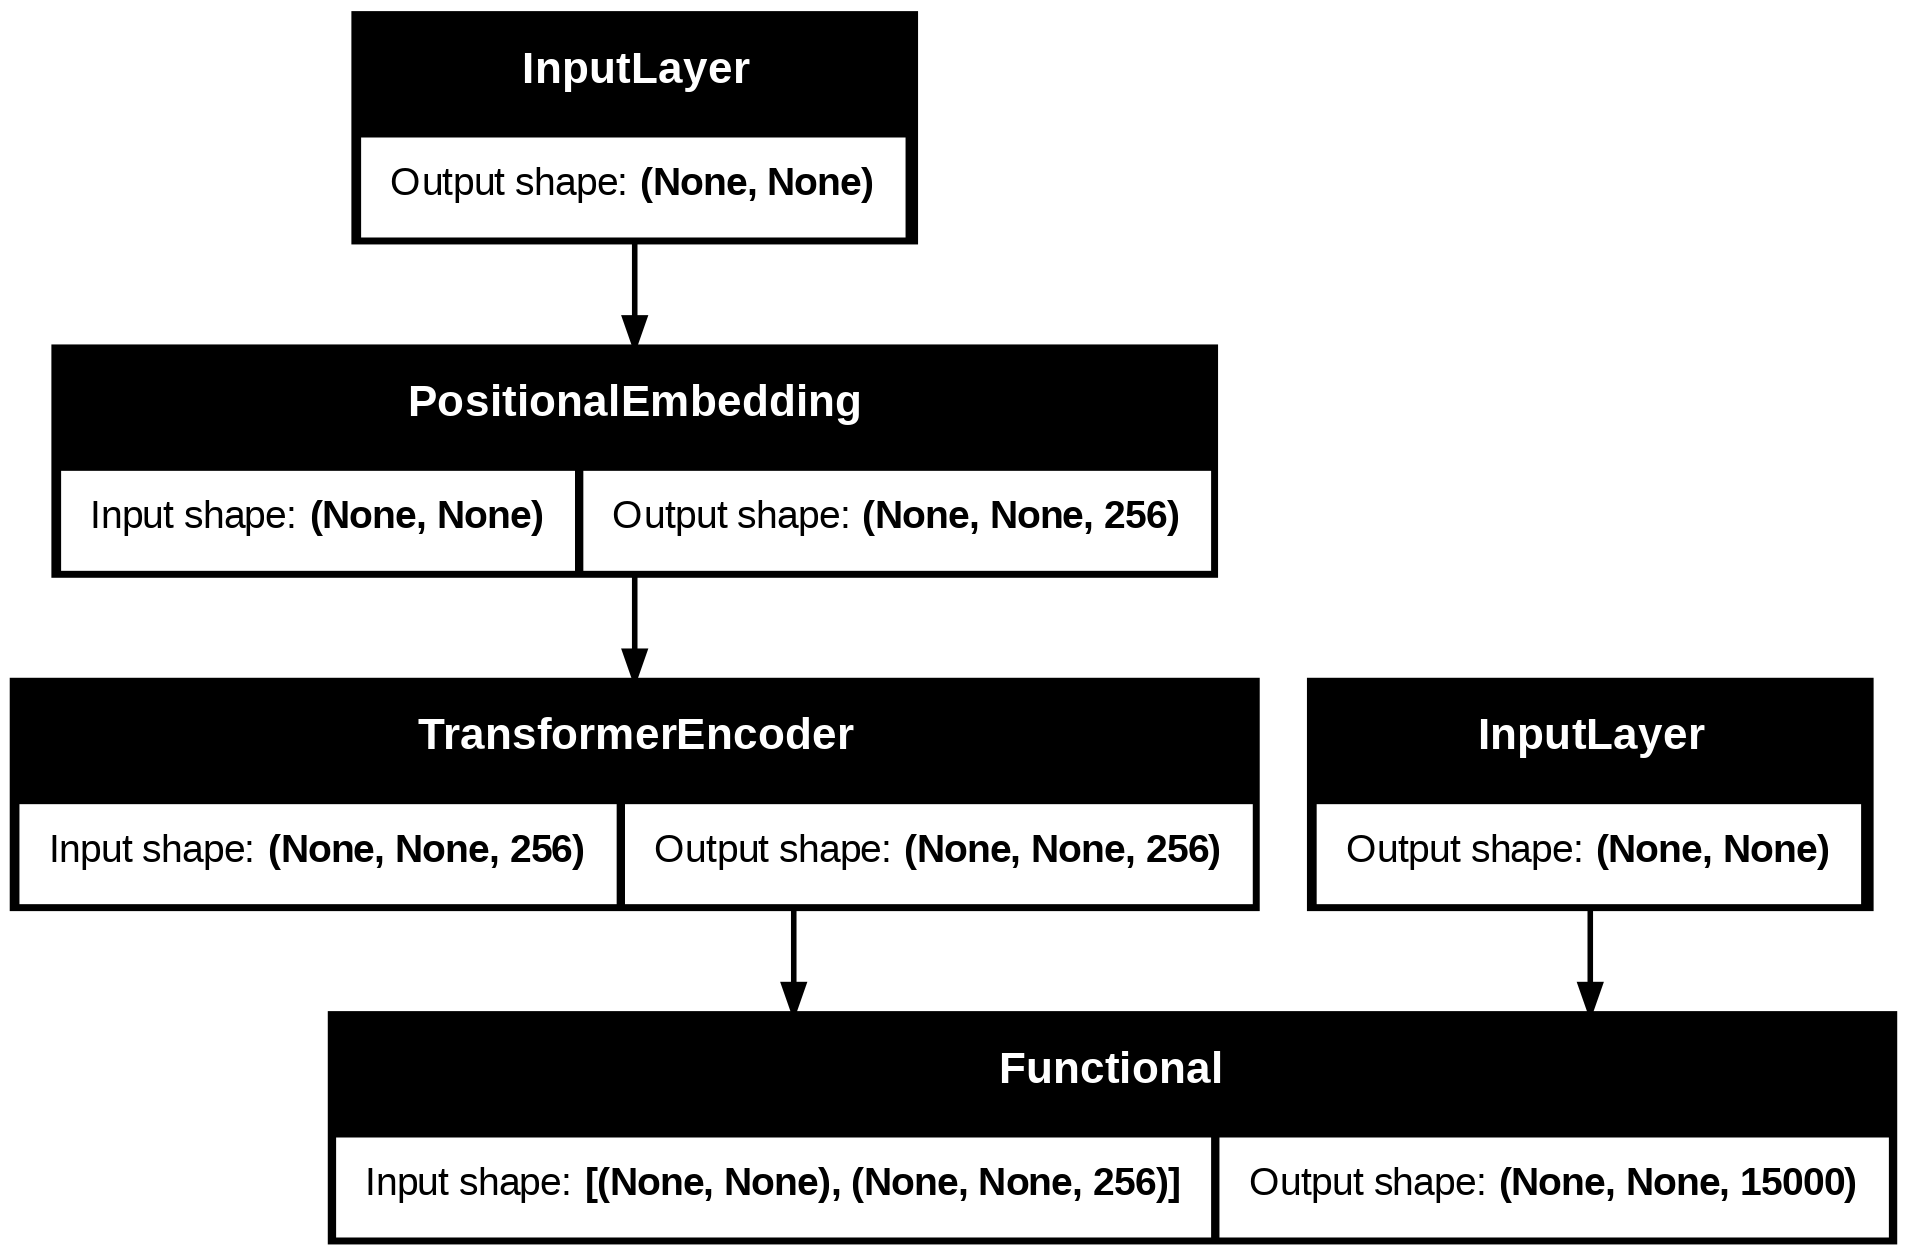

In [ ]:
keras.utils.plot_model(transformer, "my_first_model.png", show_shapes=True)

## Testing the model to decode test sentences
We feed it a Bari sentence and expect an English translation

In [ ]:
# Decoding Test Sentences

bfa_vocab = bfa_vectorization.get_vocabulary()
bfa_index_lookup = dict(zip(range(len(bfa_vocab)), bfa_vocab))
max_decoded_sentence_length = 30


def decode_sequence(input_sentence):
    tokenized_input_sentence = eng_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = bfa_vectorization([decoded_sentence])[:, :-1]
        predictions = transformer([tokenized_input_sentence, tokenized_target_sentence])  # Source of the problem

        # Check if the predicted sequence length is less than the current index
        if i >= predictions.shape[1]:
            break

        # ops.argmax(predictions[0, i, :]) is not a concrete value for jax here
        sampled_token_index = ops.convert_to_numpy(
            ops.argmax(predictions[0, i, :])
        ).item(0)
        sampled_token = bfa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token


        if sampled_token == "[end]":
            break
    return decoded_sentence

test_eng_texts = [pair[0] for pair in test_pairs]
for _ in range(30):
    input_sentence = random.choice(test_eng_texts)
    translated = decode_sequence(input_sentence)

NLP

Parameters and Hyperparameters. [These are specified elsewhere.]

In [ ]:
# Parameters A
batch_size = 4 # or 8
sequence_length = 40
vocab_size = 2500 # Adjusted for smaller dataset based on actual vocabulary size (~2025)

# Hyperparameters A
embed_dim = 256
latent_dim = 2048
num_heads = 8

In [ ]:
# Parameters B
BATCH_SIZE = 64
EPOCHS = 10  # This should be at least 10 for convergence
MAX_SEQUENCE_LENGTH = 40
ENG_VOCAB_SIZE = 15000
SPA_VOCAB_SIZE = 15000

# Hyperparameters B
EMBED_DIM = 256
INTERMEDIATE_DIM = 2048
NUM_HEADS = 8

In [ ]:
tokenized_input_sentence = eng_vectorization([input_sentence])
decoded_sentence = "[start]"
tokenized_target_sentence = bfa_vectorization([decoded_sentence])[:, :-1]
print(tokenized_input_sentence.shape)
print(tokenized_target_sentence.shape)

(1, 40)
(1, 40)


In [ ]:
print(input_sentence)
print(translated)

“Show me a denarius. Whose image and inscription are on it?” “Caesar’s,” they replied.
[start] a nye kulyani ko lepeŋ adi do a nye kulyani adi do a nye kulyani adi do a nye kulyani ko lepeŋ adi do a nye kulyani ko lepeŋ [end]


In [ ]:
print(transformer)

<Functional name=transformer, built=True>


In [ ]:
print(bfa_index_lookup)

{0: '', 1: '[UNK]', 2: np.str_('a'), 3: np.str_('ko'), 4: np.str_('i'), 5: np.str_('[start]'), 6: np.str_('[end]'), 7: np.str_('na'), 8: np.str_('lo'), 9: np.str_('adi'), 10: np.str_('nye'), 11: np.str_('se'), 12: np.str_('ta'), 13: np.str_('ti'), 14: np.str_('lepeŋ'), 15: np.str_('ŋutu'), 16: np.str_('nan'), 17: np.str_('nagon'), 18: np.str_('logon'), 19: np.str_('mo'), 20: np.str_('do'), 21: np.str_('ŋuto'), 22: np.str_('gwe'), 23: np.str_('yesu'), 24: np.str_('ama'), 25: np.str_('liŋ'), 26: np.str_('aje'), 27: np.str_('ŋo'), 28: np.str_('kogwon'), 29: np.str_('kulyani'), 30: np.str_('gwon'), 31: np.str_('nu'), 32: np.str_('kanyit'), 33: np.str_('kulya'), 34: np.str_('Ŋun'), 35: np.str_('lele'), 36: np.str_('lepeŋat'), 37: np.str_('ŋuro'), 38: np.str_('köti'), 39: np.str_('kulo'), 40: np.str_('anyen'), 41: np.str_('nyena'), 42: np.str_('kak'), 43: np.str_('kaŋo'), 44: np.str_('iŋge'), 45: np.str_('yi'), 46: np.str_('kine'), 47: np.str_('ki'), 48: np.str_('gwoso'), 49: np.str_('parik'

In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Ensure nltk data is available
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt') # Download general punkt if not found
try:
    nltk.data.find('tokenizers/punkt_tab') # Check for punkt_tab specifically
except LookupError:
    nltk.download('punkt_tab') # Download punkt_tab if not found


def clean_and_tokenize(sentence):
    """Removes [start]/[end] tokens and tokenizes the sentence."""
    # Remove [start] and [end] tokens
    cleaned_sentence = sentence.replace('[start]', '').replace('[end]', '').strip()
    # Tokenize the sentence
    return nltk.word_tokenize(cleaned_sentence)


references = []
candidates = []

# Iterate through test_pairs to get actual and predicted translations
for eng_sentence, bfa_reference in test_pairs:
    # Get the model's translated sentence
    bfa_candidate = decode_sequence(eng_sentence)

    # Clean and tokenize both candidate and reference for BLEU calculation
    tokenized_reference = clean_and_tokenize(bfa_reference)
    tokenized_candidate = clean_and_tokenize(bfa_candidate)

    # Append to lists for corpus BLEU calculation
    # corpus_bleu expects a list of reference sentences (each itself a list of tokenized words)
    # for each candidate sentence. Since we have one reference per candidate, it's [tokenized_reference]
    references.append([tokenized_reference])
    candidates.append(tokenized_candidate)

# Calculate Corpus BLEU score
# Use SmoothingFunction() for shorter sentences or when there might be zero matches for n-grams
smoother = SmoothingFunction().method1 # Or method2, method3 etc. depending on preference
corpus_bleu_score = corpus_bleu(references, candidates, smoothing_function=smoother)

print(f"Corpus BLEU Score: {corpus_bleu_score:.4f}")

# Optionally, print some example sentence BLEU scores
print("\nExample Sentence BLEU Scores:")
for i in range(5):
    idx = random.randint(0, len(test_pairs) - 1)
    eng_sentence, bfa_reference = test_pairs[idx]
    bfa_candidate = decode_sequence(eng_sentence)

    tokenized_reference = clean_and_tokenize(bfa_reference)
    tokenized_candidate = clean_and_tokenize(bfa_candidate)

    sentence_bleu_score = sentence_bleu([tokenized_reference], tokenized_candidate, smoothing_function=smoother)
    print(f"  English: {eng_sentence}")
    print(f"  Reference Bari: {' '.join(tokenized_reference)}")
    print(f"  Candidate Bari: {' '.join(tokenized_candidate)}")
    print(f"  Sentence BLEU: {sentence_bleu_score:.4f}\n")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Corpus BLEU Score: 0.0175

Example Sentence BLEU Scores:
  English: and also some women who had been cured of evil spirits and diseases: Mary (called Magdalene) from whom seven demons had come out;
  Reference Bari: se ko kunie wate nagon aje tokela i mulökö lorok ko i twana . Kine wate karin kase a ko Maria na po Magadala nagon mulökö lorok buryo a tu kaŋo kanyit i mugun ;
  Candidate Bari: a nye kulyani ko lepeŋat adi do a nye kulyani adi nan a nye kulyani adi do a nye kulyani ko lepeŋ adi do a nye kulyani ko lepeŋ adi
  Sentence BLEU: 0.0079

  English: When his parents saw him, they were astonished. His mother said to him, “Son, why have you treated us like this? Your father and I have been anxiously searching for you.”
  Reference Bari: a na meddi monye ko ŋote lepeŋ nu , a se sörji sörju , a ŋote nanyit pije lepeŋ adi , ŋuro liŋ , nyo nagon do konakindya yi sona ? Mete , yi ko munyi gwon i ga ’ yu na do ko delya a duma .
  Candidate Bari: a nye kulyani ko lepeŋat adi nan a nye ku

Test sentences